#### Parallel Execution and Reducers

Boilerplate code

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv() 

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)
if google_llm:
    print("API loaded successfully")


API loaded successfully


Nodes creation

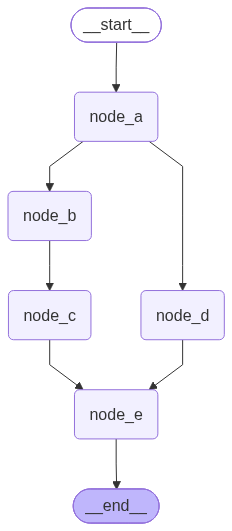

In [16]:
from langgraph.graph import StateGraph,START,END,MessagesState
from typing import TypedDict,Annotated,List
from IPython.display import display,Image
import operator
import time

class State(MessagesState):
    pass

def node_a(state : State):
    time.sleep(1)
    return{"messages":"I am A"}

def node_b(state : State):
    time.sleep(1)
    return{"messages":"I am B"}

def node_c(state : State):
    time.sleep(1)
    return{"messages":"I am C"}

def node_d(state : State):
    time.sleep(1)
    return{"messages":"I am D"}

def node_e(state : State):
    time.sleep(1)
    return{"messages":"I am E"}

builder = StateGraph(State)

# nodes
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

# edges
builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b","node_c")
builder.add_edge("node_a","node_d")
builder.add_edge("node_c","node_e")
builder.add_edge("node_d","node_e")
builder.add_edge("node_e",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




test

In [17]:
res = graph.invoke({"messages":"I am vishwa"})
for msg in res.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

I am vishwa
================================ Human Message =================================

I am A
================================ Human Message =================================

I am B
================================ Human Message =================================

I am D
================================ Human Message =================================

I am C
================================ Human Message =================================

I am E
================================ Human Message =================================

I am E


Streaming it to get the order clearly

In [20]:
events = graph.stream({"messages":"I am vishwa"},stream_mode="values")

prev_count = 0
for event in events:
    # event.get('messages')[-1].pretty_print()
    msgs = event.get('messages')
    for msg in msgs[prev_count:]:
        msg.pretty_print()
    prev_count = len(msgs)

================================ Human Message =================================

I am vishwa
================================ Human Message =================================

I am A
================================ Human Message =================================

I am B
================================ Human Message =================================

I am D
================================ Human Message =================================

I am C
================================ Human Message =================================

I am E
================================ Human Message =================================

I am E


Custom reducer to control order of execution

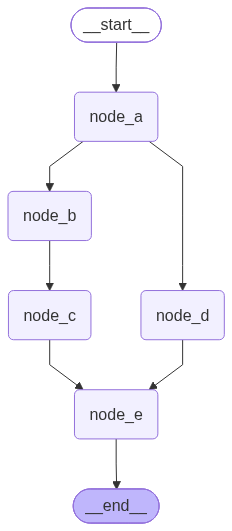

In [28]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain_core.messages import HumanMessage
from typing import TypedDict,Annotated,List
from IPython.display import display,Image
import operator
import time

def custom_reducer(left, right):
    if not isinstance(left, list):
        left = [left]
    if not isinstance(right, list):
        right = [right]
    print(f"Left is {left}")
    print(f"Right is {right}\n\n")

    return left + right

class State(TypedDict):
    messages : Annotated[list, custom_reducer]

def node_a(state : State):
    time.sleep(1)
    return{"messages":"I am A"}

def node_b(state : State):
    time.sleep(1)
    return{"messages":"I am B"}

def node_c(state : State):
    time.sleep(1)
    return{"messages":"I am C"}

def node_d(state : State):
    time.sleep(1)
    return{"messages":"I am D"}

def node_e(state : State):
    time.sleep(1)
    return{"messages":"I am E"}

builder = StateGraph(State)

# nodes
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

# edges
builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b","node_c")
builder.add_edge("node_a","node_d")
builder.add_edge("node_c","node_e")
builder.add_edge("node_d","node_e")
builder.add_edge("node_e",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




test

In [ ]:
from langchain_core.messages import HumanMessage

res = graph.stream({
    "messages": [HumanMessage(content="I am Vishwa")]
})

prev_count = 0

for event in res:
    messages = event["messages"]

    # Print only newly added messages
    for message in messages[prev_count:]:
        message.pretty_print()

    prev_count = len(messages)

Left is []
Right is [HumanMessage(content='I am Vishwa', additional_kwargs={}, response_metadata={})]


Left is [HumanMessage(content='I am Vishwa', additional_kwargs={}, response_metadata={})]
Right is ['I am A']




KeyError: 'messages'